In [1]:
import os
import pandas as pd
from scipy.stats import kruskal

In [2]:
folder = r"E:\CSV\merged"
files = os.listdir(folder)

df_names = ["CaSupp_25", "konv", "monoe_120kev", "monoe_80kev", "monoe_40kev"]

In [3]:
def kruskal_for_pair(df_myeloma, df_healthy):
    num_cols = df_healthy.select_dtypes(include=["number"]).columns
    results = []

    for col in num_cols:
        if "shape" in col:
            continue

        myeloma_group = df_myeloma[col].dropna()
        healthy_group = df_healthy[col].dropna()

        stat, p_value = kruskal(myeloma_group, healthy_group)

        if p_value < 0.05:
            results.append({
                "feature": col,
                "statistic": stat,
                "p_value": p_value
            })

    return pd.DataFrame(results).sort_values("p_value")

In [4]:
all_results = {}
for name in df_names:
    myeloma_path = os.path.join(folder, f"merged_{name}_radiomics_spine_lesions_features.csv")
    healthy_path = os.path.join(folder, f"merged_{name}_radiomics_spine_vertebrae_features.csv")

    df_myeloma = pd.read_csv(myeloma_path)
    df_healthy = pd.read_csv(healthy_path)

    results_df = kruskal_for_pair(df_myeloma, df_healthy)

    all_results[name] = results_df

In [5]:
for name, df in all_results.items():
    print(name)
    print(df.head(5))
    print()

CaSupp_25
                                    feature   statistic       p_value
10              original_firstorder_Minimum  122.577058  1.725806e-28
102             gradient_firstorder_Minimum  117.365542  2.387489e-27
0          original_firstorder_10Percentile  107.380756  3.673563e-25
4    original_firstorder_InterquartileRange  107.265088  3.894346e-25
9                original_firstorder_Median  107.261208  3.901978e-25

konv
                                   feature   statistic       p_value
4   original_firstorder_InterquartileRange  107.279101  3.866906e-25
6              original_firstorder_Maximum  107.265734  3.893075e-25
9               original_firstorder_Median  107.264010  3.896465e-25
1         original_firstorder_90Percentile  107.262932  3.898584e-25
11               original_firstorder_Range  107.259268  3.905799e-25

monoe_120kev
                                   feature   statistic       p_value
4   original_firstorder_InterquartileRange  107.283630  3.858081e-2

In [6]:
from scipy.stats import ttest_ind
import pandas as pd

def ttest_for_pair(df_myeloma, df_healthy):
    num_cols = df_healthy.select_dtypes(include=["number"]).columns
    results = []

    for col in num_cols:
        if "shape" in col:
            continue

        myeloma_group = df_myeloma[col].dropna()
        healthy_group = df_healthy[col].dropna()

        stat, p_value = ttest_ind(myeloma_group, healthy_group, equal_var=False)

        if p_value < 0.05:
            results.append({
                "feature": col,
                "statistic": stat,
                "p_value": p_value
            })

    return pd.DataFrame(results).sort_values("p_value")

In [7]:
all_results = {}
for name in df_names:
    myeloma_path = os.path.join(folder, f"merged_{name}_radiomics_spine_lesions_features.csv")
    healthy_path = os.path.join(folder, f"merged_{name}_radiomics_spine_vertebrae_features.csv")

    df_myeloma = pd.read_csv(myeloma_path)
    df_healthy = pd.read_csv(healthy_path)

    results_df = kruskal_for_pair(df_myeloma, df_healthy)

    all_results[name] = results_df

In [8]:
for name, df in all_results.items():
    print(name)
    print(df.head(5))
    print()

CaSupp_25
                                    feature   statistic       p_value
10              original_firstorder_Minimum  122.577058  1.725806e-28
102             gradient_firstorder_Minimum  117.365542  2.387489e-27
0          original_firstorder_10Percentile  107.380756  3.673563e-25
4    original_firstorder_InterquartileRange  107.265088  3.894346e-25
9                original_firstorder_Median  107.261208  3.901978e-25

konv
                                   feature   statistic       p_value
4   original_firstorder_InterquartileRange  107.279101  3.866906e-25
6              original_firstorder_Maximum  107.265734  3.893075e-25
9               original_firstorder_Median  107.264010  3.896465e-25
1         original_firstorder_90Percentile  107.262932  3.898584e-25
11               original_firstorder_Range  107.259268  3.905799e-25

monoe_120kev
                                   feature   statistic       p_value
4   original_firstorder_InterquartileRange  107.283630  3.858081e-2

# HEALTHY || STAGE I. || STAGE II. || STAGE III.

Top 10 najsignifikantnejších príznakov:
                                   Feature     H-stat   p-value
74   original_gldm_DependenceNonUniformity  23.196585  0.000037
150  gradient_glszm_GrayLevelNonUniformity  22.565854  0.000050
167  gradient_gldm_DependenceNonUniformity  22.473659  0.000052
65    original_glszm_SizeZoneNonUniformity  22.104878  0.000062
143  gradient_glrlm_RunLengthNonUniformity  21.815122  0.000071
0         original_firstorder_10Percentile  21.793666  0.000072
158   gradient_glszm_SizeZoneNonUniformity  21.621951  0.000078
107        gradient_firstorder_TotalEnergy  21.450732  0.000085
57   original_glszm_GrayLevelNonUniformity  21.134634  0.000099
50   original_glrlm_RunLengthNonUniformity  20.536098  0.000131


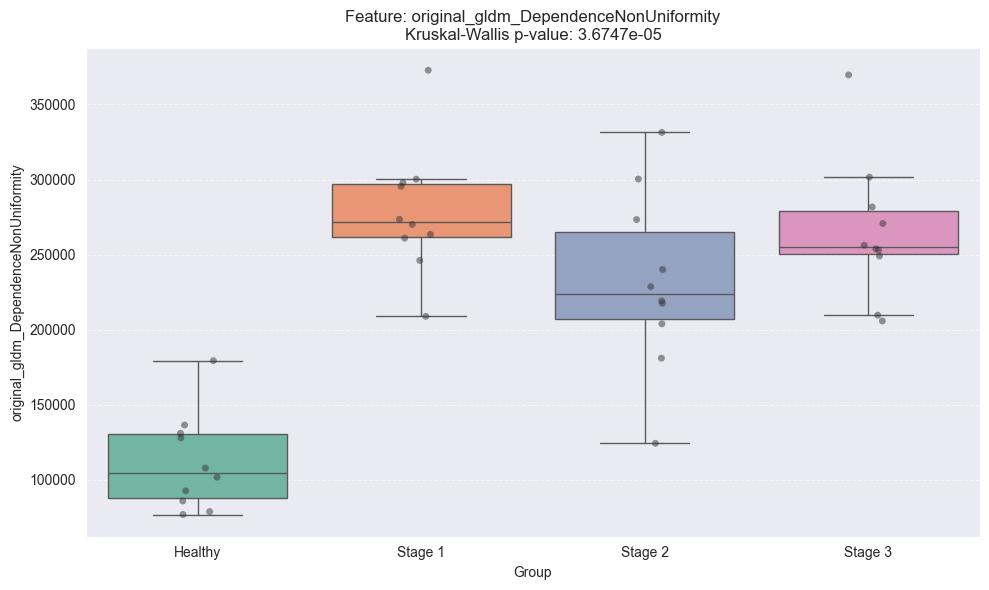

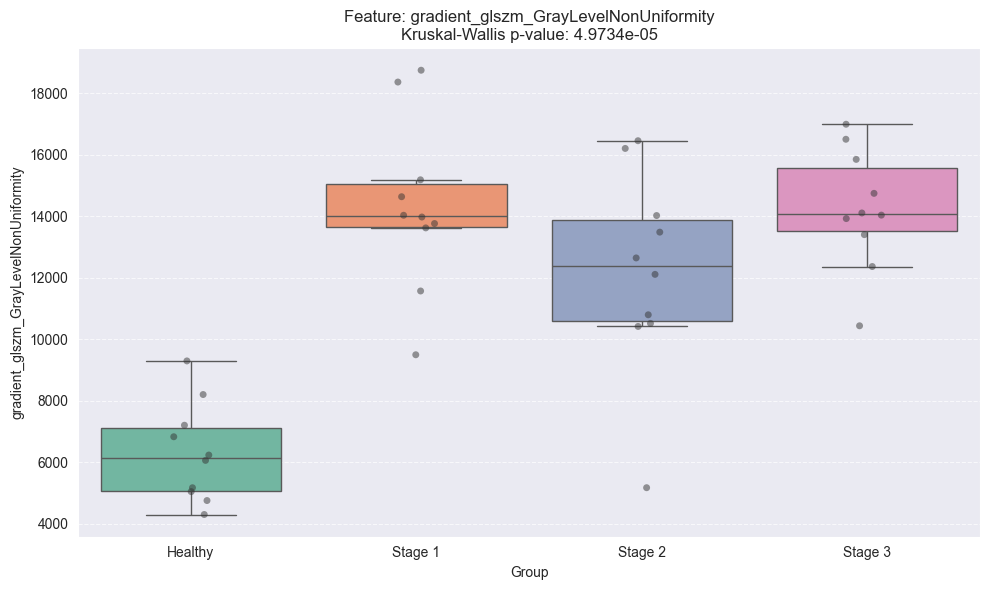

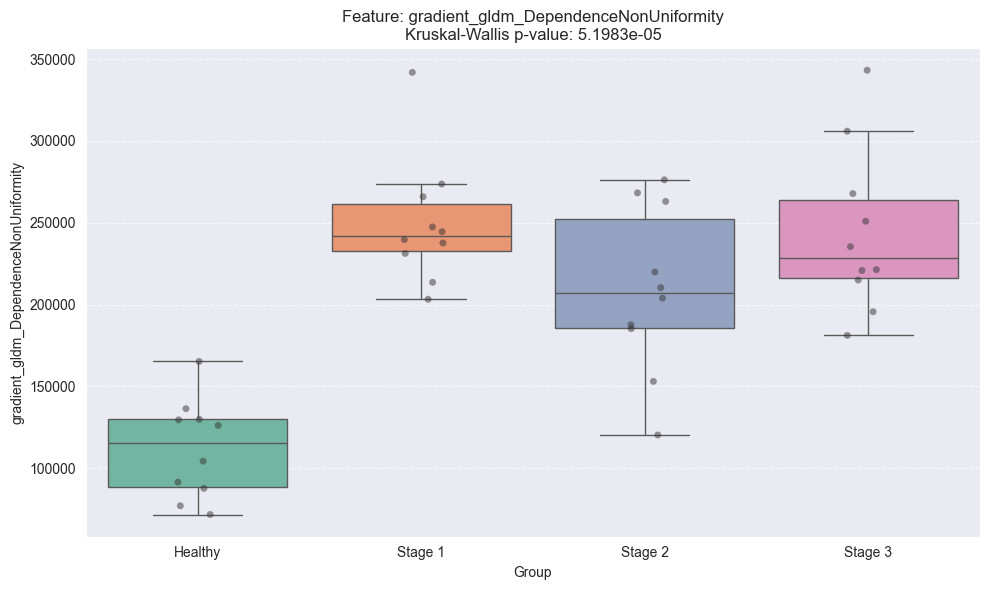

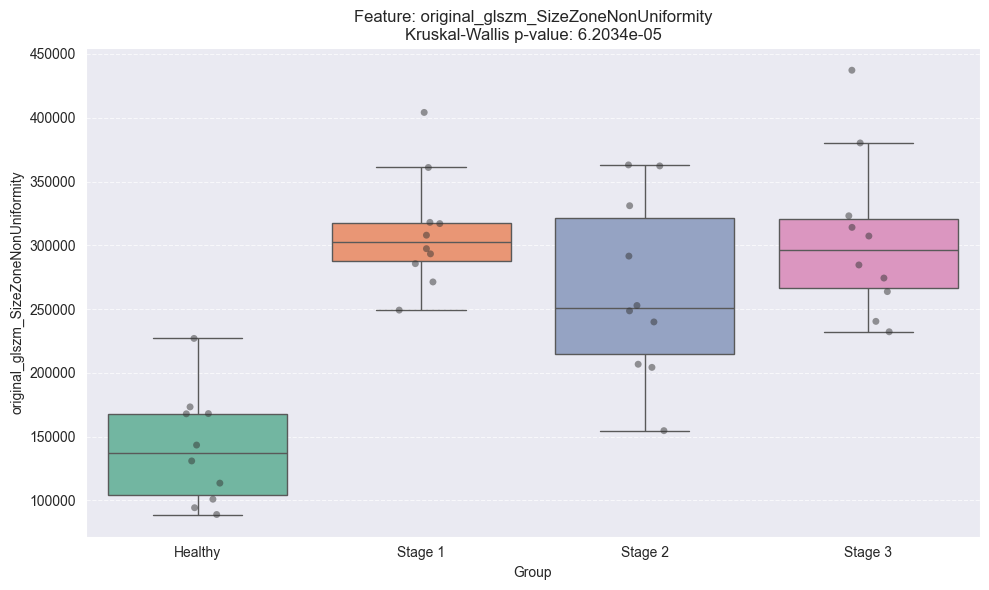

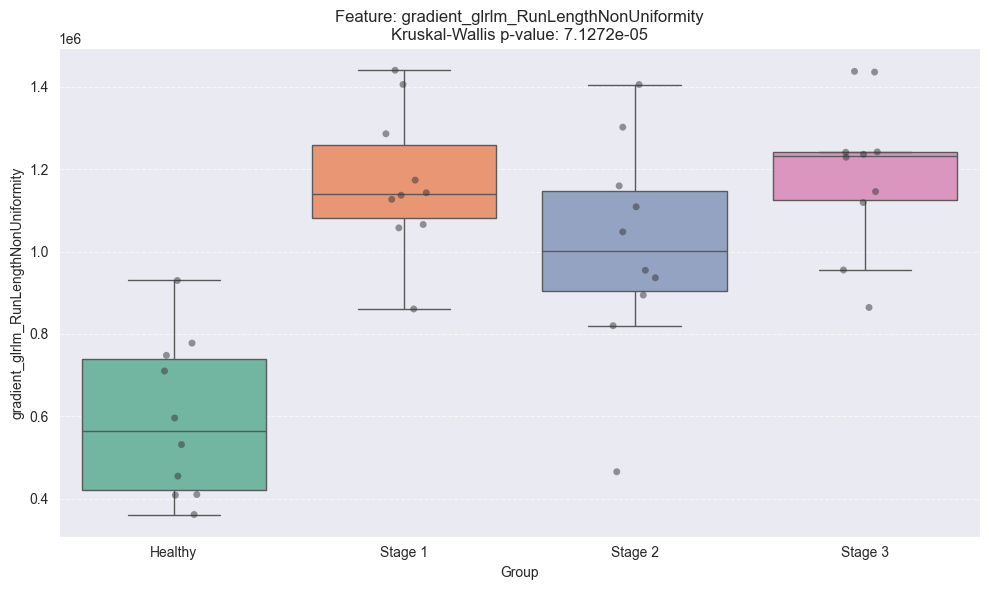

In [7]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

# 1. NASTAVENIA CESTY A SKUPÍN
main_path = r"E:\DATA_Healthy_and_Myelom"
groups = {
    "DATA_Healthy": "Healthy",
    "DATA_MM_Stage1": "Stage 1",
    "DATA_MM_Stage2": "Stage 2",
    "DATA_MM_Stage3": "Stage 3"
}
image_types = ["CaSupp_25", "konv", "monoe_40kev"]

# 2. NAČÍTANIE DÁT
all_data = []

for group_folder, group_label in groups.items():
    group_path = os.path.join(main_path, group_folder)
    if not os.path.exists(group_path): continue

    for patient_folder in os.listdir(group_path):
        patient_path = os.path.join(group_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            if file.endswith("radiomics_spine_features.csv"):
                # Extrakcia typu obrazu z názvu súboru
                img_type = None
                for it in image_types:
                    if it in file:
                        img_type = it
                        break

                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = group_label
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

# Spojenie do jedného veľkého DataFrame
full_df = pd.concat(all_data, ignore_index=True)

# 3. ANALÝZA PRE KONKRÉTNY TYP OBRAZU (napr. monoe_40kev)
selected_img = "monoe_40kev"
analysis_df = full_df[full_df['ImageType'] == selected_img].copy()

# Zoznam príznakov (všetky okrem našich pomocných stĺpcov)
features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

stats_results = []

for feat in features:
    # 1. Kontrola, či príznak nie je konštantný naprieč celým datasetom
    # Ak majú všetci pacienti rovnakú hodnotu, test nemá zmysel a vyvolal by division by zero
    if analysis_df[feat].nunique() <= 1:
        continue

    # Rozdelenie dát do skupín
    g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
    g_s1 = analysis_df[analysis_df['Group'] == "Stage 1"][feat]
    g_s2 = analysis_df[analysis_df['Group'] == "Stage 2"][feat]
    g_s3 = analysis_df[analysis_df['Group'] == "Stage 3"][feat]

    # 2. Kruskal-Wallis test s ošetrením chýb
    try:
        # Musíme zabezpečiť, aby aspoň dve skupiny mali nejaké dáta
        h_stat, p_val = kruskal(g_h, g_s1, g_s2, g_s3)

        # Ak p-hodnota vyjde NaN (napr. ak sú skupiny identické medzi sebou), preskočíme
        if not np.isnan(p_val):
            stats_results.append({'Feature': feat, 'H-stat': h_stat, 'p-value': p_val})

    except (ValueError, ZeroDivisionError):
        # Toto zachytí prípady, kedy sú všetky hodnoty v skupinách identické
        continue

# Zoradenie výsledkov podľa p-hodnoty (vzostupne)
results_df = pd.DataFrame(stats_results).sort_values('p-value')

print("Top 10 najsignifikantnejších príznakov:")
print(results_df.head(10))

# 4. VIZUALIZÁCIA TOP 5 PRÍZNAKOV
top_features = results_df['Feature'].head(5).tolist()

for feat in top_features:
    plt.figure(figsize=(10, 6))

    # Boxplot so zobrazením jednotlivých bodov (pacientov)
    sns.boxplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané: povieme, že farby (palette) sa riadia podľa 'Group'
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette="Set2",
        showfliers=False,
        legend=False  # Pridané: keďže x aj hue sú rovnaké, legenda je zbytočná
    )

    sns.stripplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané aj sem pre konzistenciu (ak by si chcel body farebné)
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette=["#333333"] * 4, # Ak chceš nechať body tmavosivé (pôvodná color=".3")
        alpha=0.5,
        legend=False
    )

    p_val_current = results_df[results_df['Feature'] == feat]['p-value'].values[0]
    plt.title(f"Feature: {feat}\nKruskal-Wallis p-value: {p_val_current:.4e}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Top 10 najsignifikantnejších príznakov:
                                               Feature     H-stat   p-value
178  gradient_gldm_SmallDependenceLowGrayLevelEmphasis  24.279512  0.000022
166              gradient_gldm_DependenceNonUniformity  22.987317  0.000041
149              gradient_glszm_GrayLevelNonUniformity  22.672683  0.000047
74               original_gldm_DependenceNonUniformity  22.382927  0.000054
65                original_glszm_SizeZoneNonUniformity  22.216098  0.000059
142              gradient_glrlm_RunLengthNonUniformity  22.046341  0.000064
106                    gradient_firstorder_TotalEnergy  21.880976  0.000069
50               original_glrlm_RunLengthNonUniformity  21.551707  0.000081
57               original_glszm_GrayLevelNonUniformity  21.458049  0.000085
51     original_glrlm_RunLengthNonUniformityNormalized  20.998537  0.000105


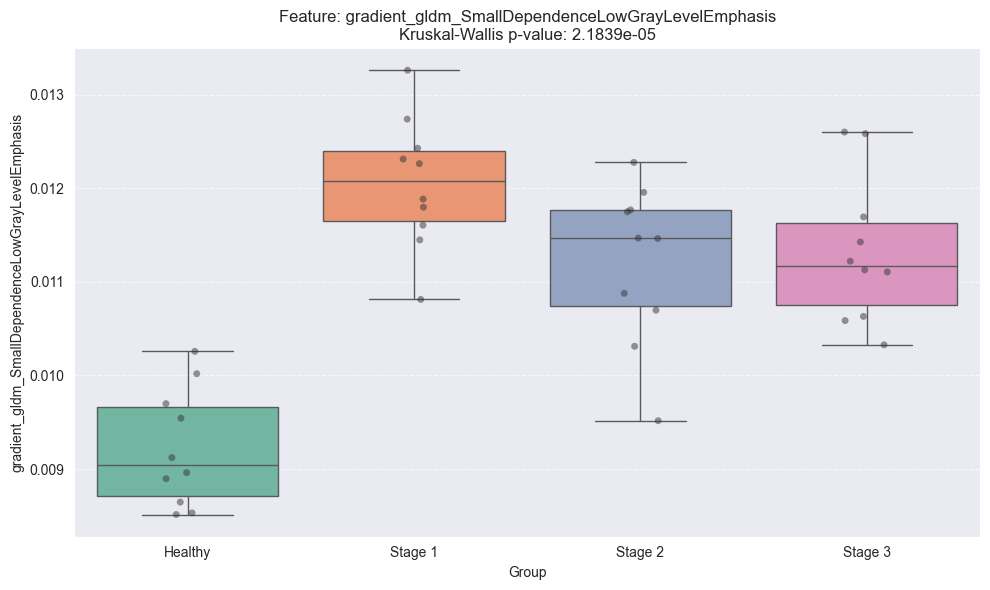

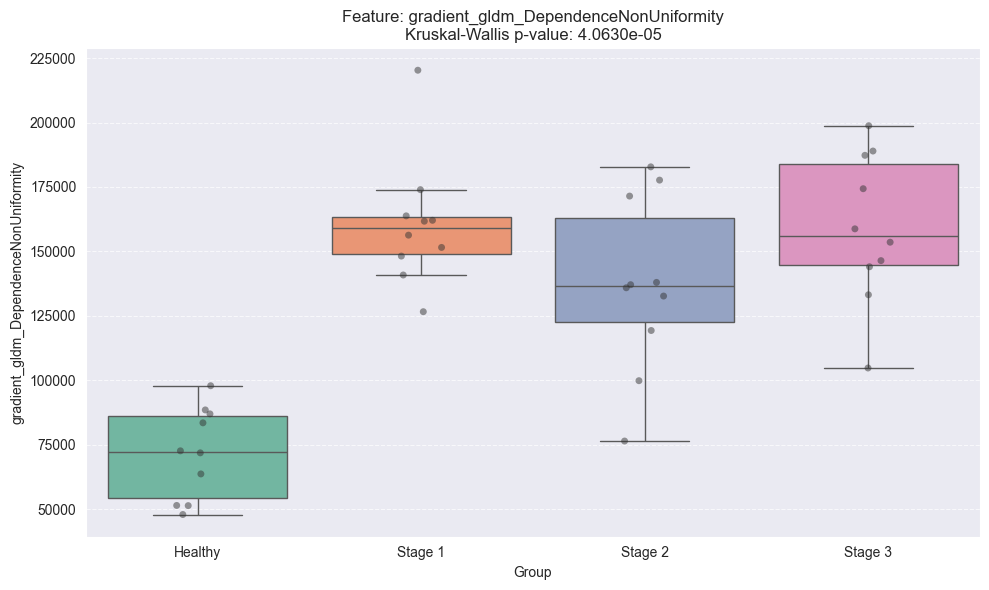

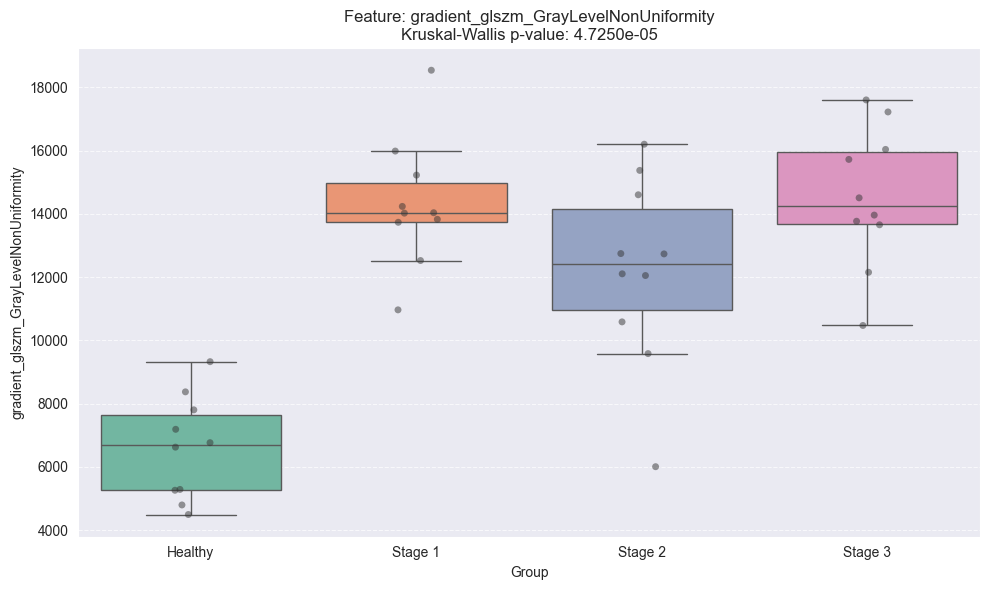

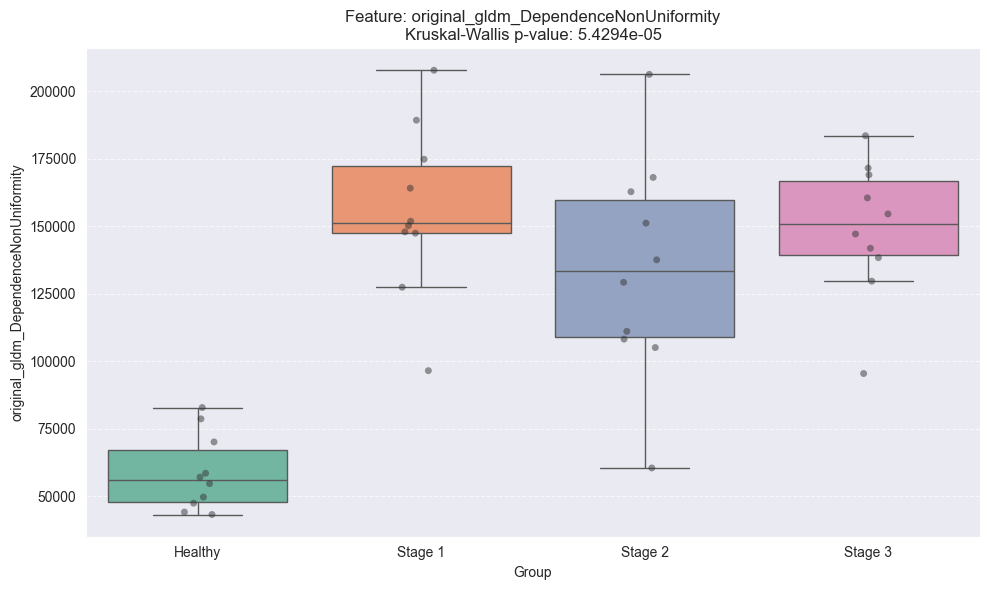

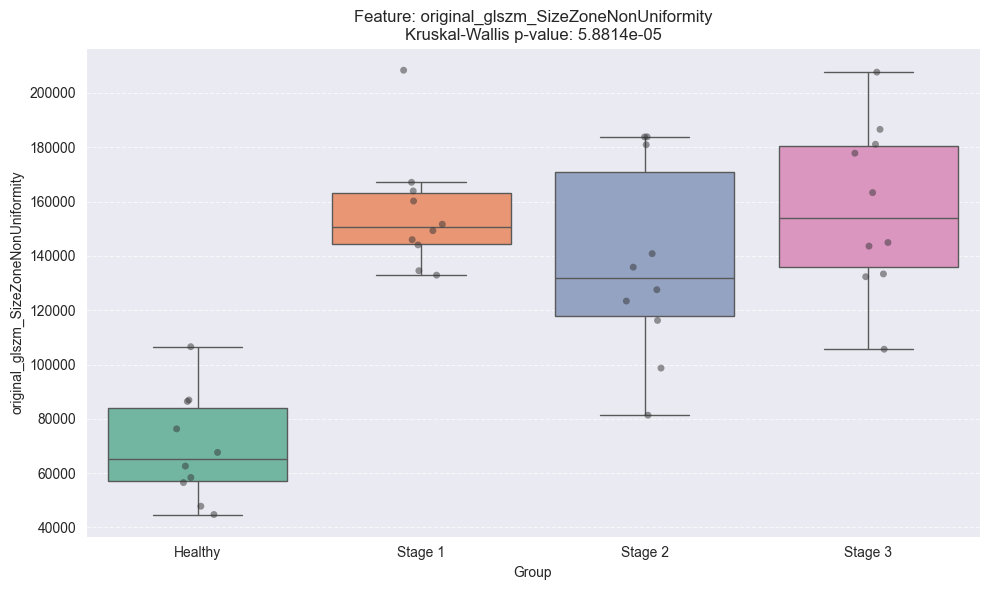

In [8]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

# 1. NASTAVENIA CESTY A SKUPÍN
main_path = r"E:\DATA_Healthy_and_Myelom"
groups = {
    "DATA_Healthy": "Healthy",
    "DATA_MM_Stage1": "Stage 1",
    "DATA_MM_Stage2": "Stage 2",
    "DATA_MM_Stage3": "Stage 3"
}
image_types = ["CaSupp_25", "konv", "monoe_40kev"]

# 2. NAČÍTANIE DÁT
all_data = []

for group_folder, group_label in groups.items():
    group_path = os.path.join(main_path, group_folder)
    if not os.path.exists(group_path): continue

    for patient_folder in os.listdir(group_path):
        patient_path = os.path.join(group_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            if file.endswith("radiomics_spine_features.csv"):
                # Extrakcia typu obrazu z názvu súboru
                img_type = None
                for it in image_types:
                    if it in file:
                        img_type = it
                        break

                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = group_label
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

# Spojenie do jedného veľkého DataFrame
full_df = pd.concat(all_data, ignore_index=True)

# 3. ANALÝZA PRE KONKRÉTNY TYP OBRAZU (napr. monoe_40kev)
selected_img = "CaSupp_25"
analysis_df = full_df[full_df['ImageType'] == selected_img].copy()

# Zoznam príznakov (všetky okrem našich pomocných stĺpcov)
features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

stats_results = []

for feat in features:
    # 1. Kontrola, či príznak nie je konštantný naprieč celým datasetom
    # Ak majú všetci pacienti rovnakú hodnotu, test nemá zmysel a vyvolal by division by zero
    if analysis_df[feat].nunique() <= 1:
        continue

    # Rozdelenie dát do skupín
    g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
    g_s1 = analysis_df[analysis_df['Group'] == "Stage 1"][feat]
    g_s2 = analysis_df[analysis_df['Group'] == "Stage 2"][feat]
    g_s3 = analysis_df[analysis_df['Group'] == "Stage 3"][feat]

    # 2. Kruskal-Wallis test s ošetrením chýb
    try:
        # Musíme zabezpečiť, aby aspoň dve skupiny mali nejaké dáta
        h_stat, p_val = kruskal(g_h, g_s1, g_s2, g_s3)

        # Ak p-hodnota vyjde NaN (napr. ak sú skupiny identické medzi sebou), preskočíme
        if not np.isnan(p_val):
            stats_results.append({'Feature': feat, 'H-stat': h_stat, 'p-value': p_val})

    except (ValueError, ZeroDivisionError):
        # Toto zachytí prípady, kedy sú všetky hodnoty v skupinách identické
        continue

# Zoradenie výsledkov podľa p-hodnoty (vzostupne)
results_df = pd.DataFrame(stats_results).sort_values('p-value')

print("Top 10 najsignifikantnejších príznakov:")
print(results_df.head(10))

# 4. VIZUALIZÁCIA TOP 5 PRÍZNAKOV
top_features = results_df['Feature'].head(5).tolist()

for feat in top_features:
    plt.figure(figsize=(10, 6))

    # Boxplot so zobrazením jednotlivých bodov (pacientov)
    sns.boxplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané: povieme, že farby (palette) sa riadia podľa 'Group'
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette="Set2",
        showfliers=False,
        legend=False  # Pridané: keďže x aj hue sú rovnaké, legenda je zbytočná
    )

    sns.stripplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané aj sem pre konzistenciu (ak by si chcel body farebné)
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette=["#333333"] * 4, # Ak chceš nechať body tmavosivé (pôvodná color=".3")
        alpha=0.5,
        legend=False
    )

    p_val_current = results_df[results_df['Feature'] == feat]['p-value'].values[0]
    plt.title(f"Feature: {feat}\nKruskal-Wallis p-value: {p_val_current:.4e}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Top 10 najsignifikantnejších príznakov:
                                   Feature     H-stat   p-value
124                     gradient_glcm_Imc1  25.273171  0.000014
77        original_gldm_DependenceVariance  24.920488  0.000016
131       gradient_glcm_MaximumProbability  24.721463  0.000018
170       gradient_gldm_DependenceVariance  24.616098  0.000019
66    original_glszm_SizeZoneNonUniformity  24.563415  0.000019
147             gradient_glrlm_RunVariance  24.481463  0.000020
38        original_glcm_MaximumProbability  24.463902  0.000020
81   original_gldm_LargeDependenceEmphasis  24.367317  0.000021
54              original_glrlm_RunVariance  24.354146  0.000021
46          original_glrlm_LongRunEmphasis  24.354146  0.000021


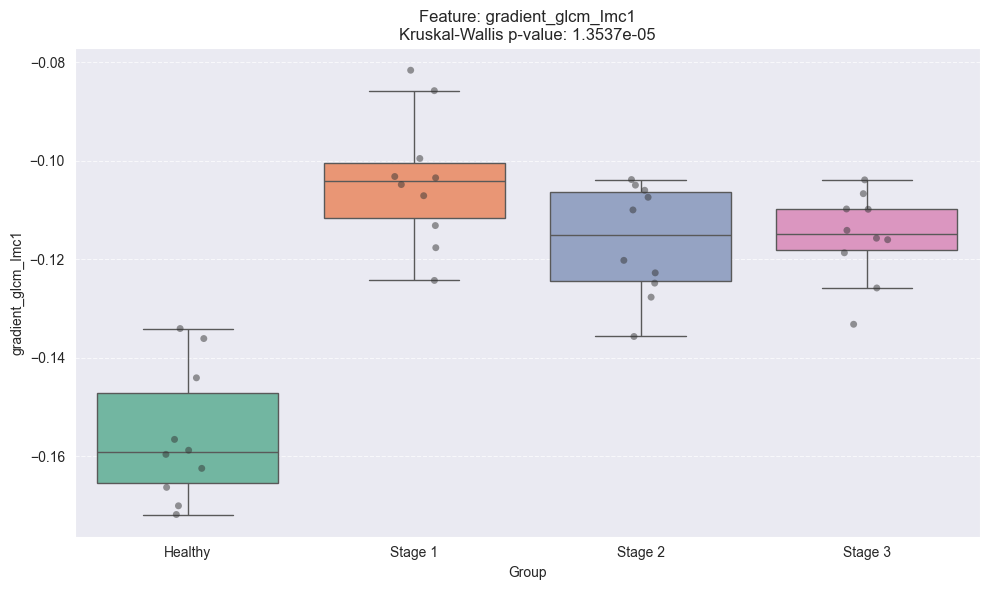

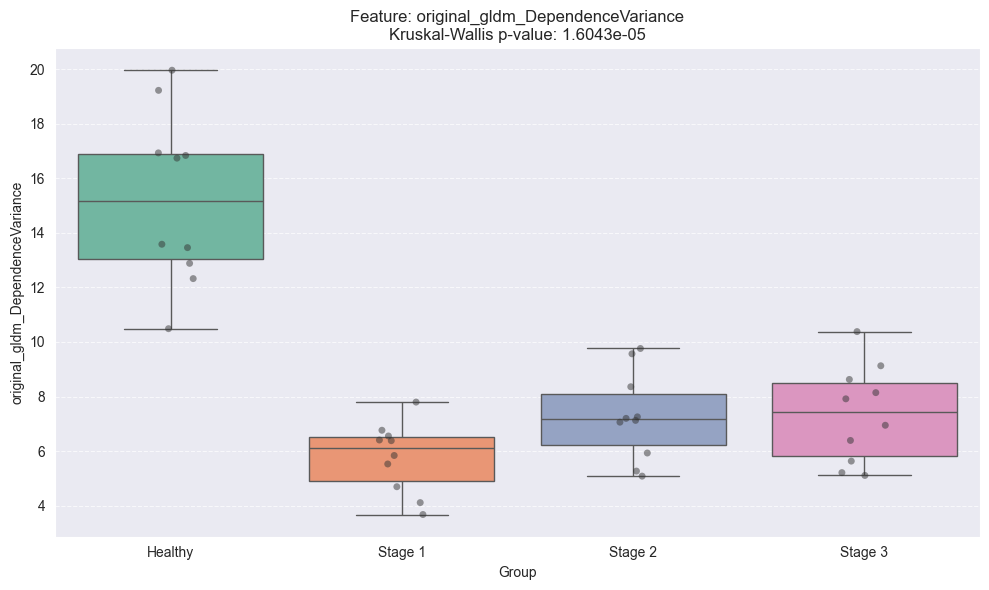

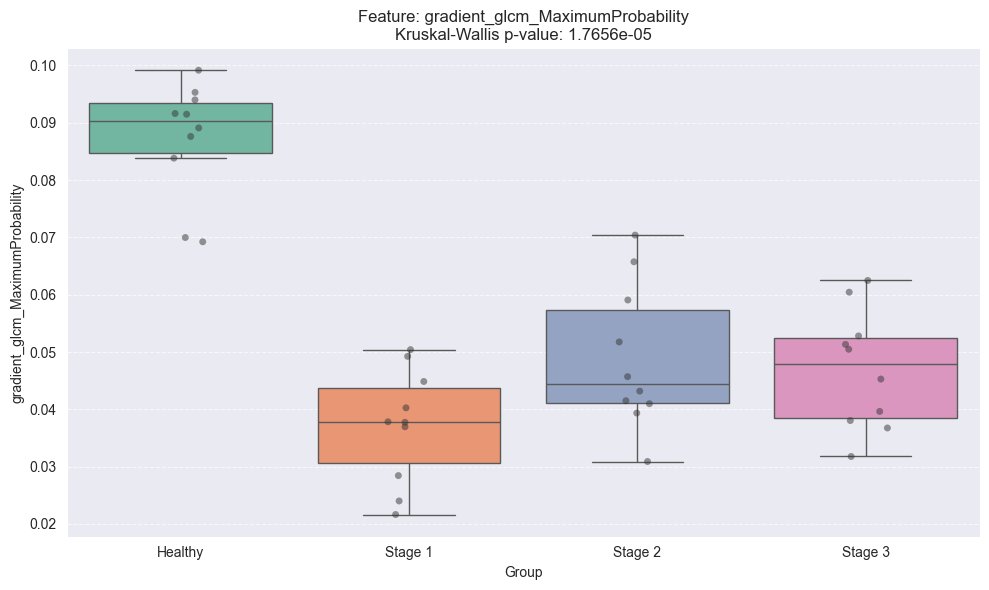

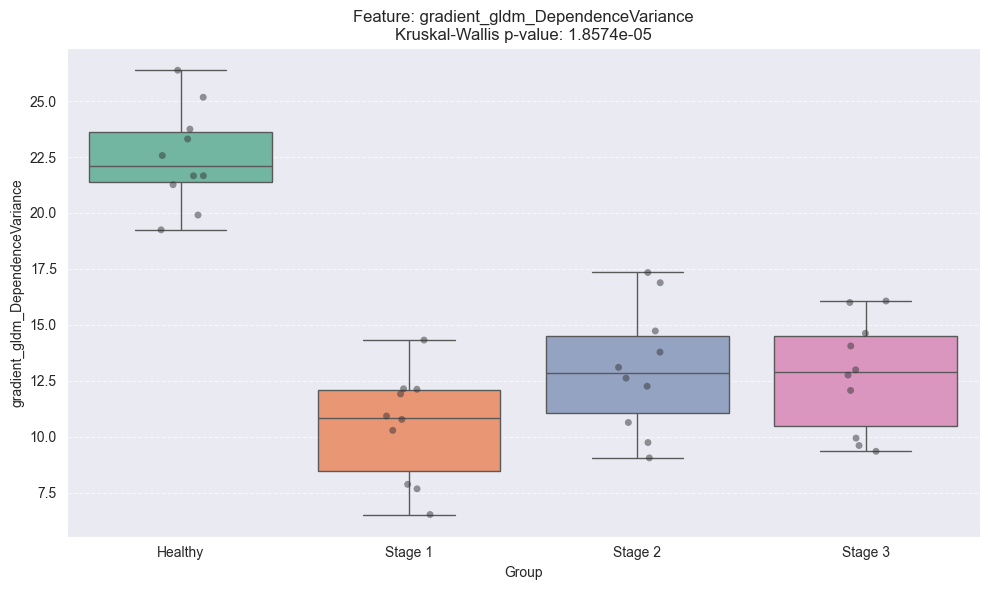

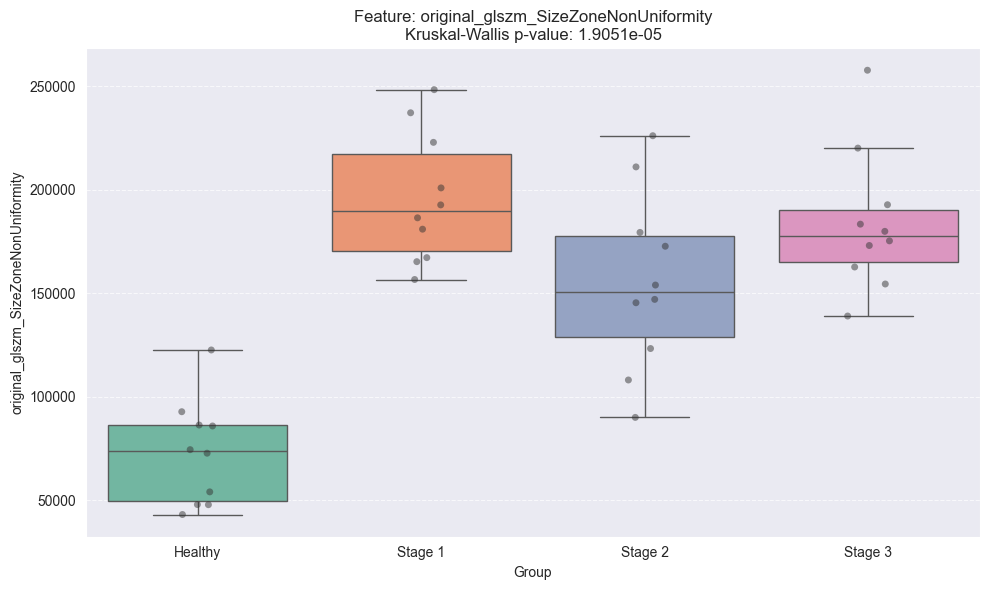

In [9]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kruskal
import seaborn as sns
import matplotlib.pyplot as plt

# 1. NASTAVENIA CESTY A SKUPÍN
main_path = r"E:\DATA_Healthy_and_Myelom"
groups = {
    "DATA_Healthy": "Healthy",
    "DATA_MM_Stage1": "Stage 1",
    "DATA_MM_Stage2": "Stage 2",
    "DATA_MM_Stage3": "Stage 3"
}
image_types = ["CaSupp_25", "konv", "monoe_40kev"]

# 2. NAČÍTANIE DÁT
all_data = []

for group_folder, group_label in groups.items():
    group_path = os.path.join(main_path, group_folder)
    if not os.path.exists(group_path): continue

    for patient_folder in os.listdir(group_path):
        patient_path = os.path.join(group_path, patient_folder)
        if not os.path.isdir(patient_path): continue

        for file in os.listdir(patient_path):
            if file.endswith("radiomics_spine_features.csv"):
                # Extrakcia typu obrazu z názvu súboru
                img_type = None
                for it in image_types:
                    if it in file:
                        img_type = it
                        break

                if img_type:
                    df_temp = pd.read_csv(os.path.join(patient_path, file))
                    df_temp['Group'] = group_label
                    df_temp['ImageType'] = img_type
                    df_temp['Patient'] = patient_folder
                    all_data.append(df_temp)

# Spojenie do jedného veľkého DataFrame
full_df = pd.concat(all_data, ignore_index=True)

# 3. ANALÝZA PRE KONKRÉTNY TYP OBRAZU (napr. monoe_40kev)
selected_img = "konv"
analysis_df = full_df[full_df['ImageType'] == selected_img].copy()

# Zoznam príznakov (všetky okrem našich pomocných stĺpcov)
features = [col for col in analysis_df.columns if col not in ['Group', 'ImageType', 'Patient']]

stats_results = []

for feat in features:
    # 1. Kontrola, či príznak nie je konštantný naprieč celým datasetom
    # Ak majú všetci pacienti rovnakú hodnotu, test nemá zmysel a vyvolal by division by zero
    if analysis_df[feat].nunique() <= 1:
        continue

    # Rozdelenie dát do skupín
    g_h = analysis_df[analysis_df['Group'] == "Healthy"][feat]
    g_s1 = analysis_df[analysis_df['Group'] == "Stage 1"][feat]
    g_s2 = analysis_df[analysis_df['Group'] == "Stage 2"][feat]
    g_s3 = analysis_df[analysis_df['Group'] == "Stage 3"][feat]

    # 2. Kruskal-Wallis test s ošetrením chýb
    try:
        # Musíme zabezpečiť, aby aspoň dve skupiny mali nejaké dáta
        h_stat, p_val = kruskal(g_h, g_s1, g_s2, g_s3)

        # Ak p-hodnota vyjde NaN (napr. ak sú skupiny identické medzi sebou), preskočíme
        if not np.isnan(p_val):
            stats_results.append({'Feature': feat, 'H-stat': h_stat, 'p-value': p_val})

    except (ValueError, ZeroDivisionError):
        # Toto zachytí prípady, kedy sú všetky hodnoty v skupinách identické
        continue

# Zoradenie výsledkov podľa p-hodnoty (vzostupne)
results_df = pd.DataFrame(stats_results).sort_values('p-value')

print("Top 10 najsignifikantnejších príznakov:")
print(results_df.head(10))

# 4. VIZUALIZÁCIA TOP 5 PRÍZNAKOV
top_features = results_df['Feature'].head(5).tolist()

for feat in top_features:
    plt.figure(figsize=(10, 6))

    # Boxplot so zobrazením jednotlivých bodov (pacientov)
    sns.boxplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané: povieme, že farby (palette) sa riadia podľa 'Group'
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette="Set2",
        showfliers=False,
        legend=False  # Pridané: keďže x aj hue sú rovnaké, legenda je zbytočná
    )

    sns.stripplot(
        data=analysis_df,
        x='Group',
        y=feat,
        hue='Group',  # Pridané aj sem pre konzistenciu (ak by si chcel body farebné)
        order=["Healthy", "Stage 1", "Stage 2", "Stage 3"],
        palette=["#333333"] * 4, # Ak chceš nechať body tmavosivé (pôvodná color=".3")
        alpha=0.5,
        legend=False
    )

    p_val_current = results_df[results_df['Feature'] == feat]['p-value'].values[0]
    plt.title(f"Feature: {feat}\nKruskal-Wallis p-value: {p_val_current:.4e}")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()